# 🎮 Freemium Mobile Gaming: Monetization & Player Retention Analysis
**Author:** Akash Kumar Singh
**Dataset:** Mobile Game In-App Purchases (3,024 players across 15+ game genres)

---

## 📋 Executive Summary & Key Findings
This Exploratory Data Analysis (EDA) investigates mobile gaming telemetry and transactional data to uncover the core drivers of revenue, user segmentation behavior, and engagement dynamics. By isolating the paying user cohort from the Free-to-Play (F2P) base, we uncover actionable insights for monetization and user acquisition strategies.

### 🌟 Key Findings at a Glance:
* **The Freemium Conversion Baseline:** Out of 3,024 tracked users, exactly 136 players (~4.5%) represent a strict Free-to-Play (F2P) base that has never converted. The remaining 2,887 users are active payers generating a total revenue of $296,259.31.
* **Extreme "Whale" Concentration (Pareto Principle):** Monetization relies heavily on a microscopic fraction of the player base. "Whales" (high-spending segment) make up just ~2.3% of paying users, yet they single-handedly drive **59.2% of total gross revenue** ($175,583+). Conversely, "Minnows" account for ~88% of payers but contribute only 8.2% of total revenue.
* **The Engagement Myth:** A correlation matrix and scatter analysis proved that baseline player engagement (`SessionCount` and `AverageSessionLength`) has **virtually zero correlation (r ≈ 0.04 and -0.03)** with in-app purchase amounts. Simply keeping a user in the app longer does not naturally turn them into a high-spender.
* **Platform Disparity (Android vs. iOS):** Android captures higher aggregate user volume and total revenue ($157k), but iOS users demonstrate a higher Average Revenue Per Paying User (ARPU) at $111.15 compared to Android's $94.67.
* **Genre Monetization Depth:** Adventure, MOBA, and Fighting games extract the highest average spend ceilings from their Whale cohorts (averaging $3,500 to $4,900+ per user), whereas Casual and Action RPG genres cap out much earlier.

---

### 1. Importing Important Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Loading the dataset

In [2]:
df = pd.read_csv("mobile_game_inapp_purchases.csv")
df.head()

,UserID,Age,Gender,Country,Device,GameGenre,SessionCount,AverageSessionLength,SpendingSegment,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,PaymentMethod,LastPurchaseDate
0,c9889ab0-9cfc-4a75-acd9-5eab1df0015c,49.0,Male,Norway,Android,Battle Royale,9,12.83,Minnow,11.40,28.0,Apple Pay,2025-03-19
1,7c9e413c-ecca-45f2-a780-2826a07952a2,15.0,Male,Switzerland,iOS,Action RPG,11,19.39,Minnow,6.37,18.0,Debit Card,2025-06-08
2,fd61e419-1a92-4f43-a8c7-135842ad328a,23.0,Male,China,Android,Fighting,9,8.87,Minnow,15.81,30.0,Apple Pay,2025-06-02
3,bdb7f6d1-ff9a-468c-afe7-43f32a94293e,31.0,Male,Mexico,Android,Racing,12,19.56,Minnow,13.49,9.0,Debit Card,2025-04-01
4,aa7eec14-4846-47b9-b879-9c98038cda04,37.0,Female,India,Android,Battle Royale,10,15.23,Minnow,10.86,15.0,Paypal,2025-05-05


### 3. Dataset Overview
This comprehensive synthetic dataset contains detailed information about mobile game players and their in-app purchase behaviors, specifically designed for analyzing spending patterns and user segmentation in the mobile gaming industry. The dataset focuses on the classic "whales vs minnows" segmentation model, providing insights into different player spending categories and their gaming habits.

<b>Dataset Characteristics</b>
-  Total Records: 3,024 user entries
-  Features: 13 columns covering user demographics, gaming behavior, and transaction data
-  Target Application: Mobile game monetization analysis, user behavior prediction, and revenue optimization
-  Data Quality: Contains realistic null values (~2-5%) to simulate real-world data collection scenarios

In [3]:
df.columns

Index(['UserID', 'Age', 'Gender', 'Country', 'Device', 'GameGenre',
       'SessionCount', 'AverageSessionLength', 'SpendingSegment',
       'InAppPurchaseAmount', 'FirstPurchaseDaysAfterInstall', 'PaymentMethod',
       'LastPurchaseDate'],
      dtype='object')

##### Columns Description
- <b>UserId</b>: Unique identifier for each user
- <b>Age</b>: User's age in years
- <b>Gender</b>: User's gender identity
- <b>Country</b>: User's country of origin
- <b>Device</b>: Mobile platform used
- <b>GameGenre</b>: Primary game genre played
- <b>SessionCount</b>: Number of gaming sessions
- <b>AverageSessionLength</b>: Average session duration in minutes
- <b>SpendingSegment</b>: Player spending classification
- <b>InAppPurchaseAmount</b>: Total purchase amount in USD
- <b>FirstPurchaseDaysAfterInstall</b>: Days until first purchase
- <b>PaymentMethod</b>: Preferred payment gateway
- <b>LastPurchaseDate</b>: Most recent purchase timestamp

In [4]:
df.shape

(3024, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   UserID                         3024 non-null   object 
 1   Age                            2964 non-null   float64
 2   Gender                         2964 non-null   object 
 3   Country                        2964 non-null   object 
 4   Device                         2964 non-null   object 
 5   GameGenre                      2964 non-null   object 
 6   SessionCount                   3024 non-null   int64  
 7   AverageSessionLength           3024 non-null   float64
 8   SpendingSegment                3024 non-null   object 
 9   InAppPurchaseAmount            2888 non-null   float64
 10  FirstPurchaseDaysAfterInstall  2888 non-null   float64
 11  PaymentMethod                  2888 non-null   object 
 12  LastPurchaseDate               2888 non-null   o

In [6]:
df.describe()

,Age,SessionCount,AverageSessionLength,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall
count,2964.000000,3024.000000,3024.000000,2888.000000,2888.000000
mean,33.533738,10.074735,20.073978,102.582864,15.384003
std,11.992258,3.115863,8.585208,454.339708,8.946191
min,13.000000,1.000000,5.010000,0.000000,0.000000
25%,23.000000,8.000000,12.680000,5.987500,8.000000
50%,33.000000,10.000000,20.315000,11.975000,16.000000
75%,44.000000,12.000000,27.420000,17.762500,23.000000
max,54.000000,22.000000,34.990000,4964.450000,30.000000


### 4. Data Cleaning

In [7]:
df.isnull().sum()

UserID                             0
Age                               60
Gender                            60
Country                           60
Device                            60
GameGenre                         60
SessionCount                       0
AverageSessionLength               0
SpendingSegment                    0
InAppPurchaseAmount              136
FirstPurchaseDaysAfterInstall    136
PaymentMethod                    136
LastPurchaseDate                 136
dtype: int64

In [37]:
print(f'Number Of Duplicate Rows: {df.duplicated().sum()}')

Number Of Duplicate Rows: 0


In [9]:
paying_user_df = df[df['InAppPurchaseAmount'] > 0].copy()

Removed the pure f2p players from the dataset

In [10]:
paying_user_df.isnull().sum()

UserID                            0
Age                              53
Gender                           59
Country                          60
Device                           56
GameGenre                        57
SessionCount                      0
AverageSessionLength              0
SpendingSegment                   0
InAppPurchaseAmount               0
FirstPurchaseDaysAfterInstall     0
PaymentMethod                     0
LastPurchaseDate                  0
dtype: int64

<b>Handling the null values:</b>

In [ ]:
paying_user_df['Age'] = paying_user_df['Age'].fillna(paying_user_df['Age'].median())
paying_user_df['Gender'] = paying_user_df['Gender'].fillna('Unknown')
paying_user_df['Country'] = paying_user_df['Country'].fillna('Unknown')
paying_user_df['Device'] = paying_user_df['Device'].fillna('Other')
paying_user_df['GameGenre'] = paying_user_df['GameGenre'].fillna('Other')

In [12]:
paying_user_df['LastPurchaseDate'] = pd.to_datetime(paying_user_df['LastPurchaseDate'], errors='coerce')

In [13]:
numerical_columns = paying_user_df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = paying_user_df.select_dtypes(include=['object']).columns

In [14]:
print(f"Numerical Columns: {numerical_columns}")
print(f"Categorical Columns: {categorical_columns}")

Numerical Columns: Index(['Age', 'SessionCount', 'AverageSessionLength', 'InAppPurchaseAmount',
       'FirstPurchaseDaysAfterInstall'],
      dtype='object')
Categorical Columns: Index(['UserID', 'Gender', 'Country', 'Device', 'GameGenre', 'SpendingSegment',
       'PaymentMethod'],
      dtype='object')


In [15]:
for col in categorical_columns:
    if col != 'UserID':
        print(f"\nUnique Values for {col}:")
        print(df[col].value_counts())


Unique Values for Gender:
Gender
Male      1810
Female    1098
Other       56
Name: count, dtype: int64

Unique Values for Country:
Country
India           242
Switzerland     119
Saudi Arabia    116
Mexico          115
Netherlands     114
Germany         114
Australia       113
Japan           112
Italy           112
UK              108
Norway          107
USA             107
Sweden          106
Denmark         106
Iran            105
Brazil          105
Canada          105
South Korea     103
China           101
Egypt           101
Bangladesh      101
Spain            96
Russia           93
Afghanistan      93
France           92
Turkey           90
Sri Lanka        88
Name: count, dtype: int64

Unique Values for Device:
Device
Android    1738
iOS        1226
Name: count, dtype: int64

Unique Values for GameGenre:
GameGenre
Simulation       219
Sandbox          219
Sports           217
Casual           209
Puzzle           206
Card             202
MMORPG           198
Strategy      

In [16]:
total_users = paying_user_df['UserID'].nunique()
total_revenue = paying_user_df['InAppPurchaseAmount'].sum()
avg_revenue_per_user = paying_user_df.groupby('UserID')['InAppPurchaseAmount'].sum().mean()
print(f"Total Users: {total_users}")
print(f"Total Revenue: {total_revenue}")
print(f"Avg Revenue Per User: {avg_revenue_per_user}")

Total Users: 2887
Total Revenue: 296259.30999999994
Avg Revenue Per User: 102.61839625909248


In [41]:
pivot_table = paying_user_df.pivot_table(
    index= 'GameGenre',
    columns = "SpendingSegment",
    values = 'InAppPurchaseAmount',
    aggfunc= 'mean'
).round(2)

In [42]:
pivot_table

SpendingSegment,Dolphin,Minnow,Whale
GameGenre,,,
Action RPG,227.22,9.93,1597.61
Adventure,267.43,9.24,4930.28
Battle Royale,246.46,9.73,2955.91
Card,237.52,10.27,3291.58
Casual,273.34,10.86,1899.08
Fighting,268.61,9.78,3565.38
MMORPG,242.93,9.68,3374.39
MOBA,213.59,10.48,3632.84
Other,266.24,10.20,3382.23


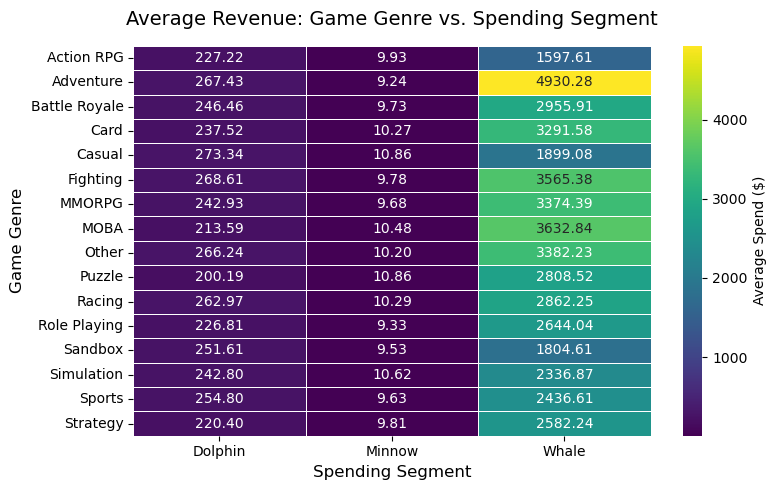

In [44]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot_table, 
    annot=True, 
    fmt='.2f', 
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Average Spend ($)'}
)

plt.title("Average Revenue: Game Genre vs. Spending Segment", pad=15, fontsize=14)
plt.xlabel("Spending Segment", fontsize=12)
plt.ylabel("Game Genre", fontsize=12)
plt.tight_layout()

### 5. Monetization Depth Analysis: Genre vs. Spending Segment
Calculating a single "Average Revenue Per User" (ARPU) across an entire game portfolio is often misleading. Spending behavior is highly dependent on both the product offering (Game Genre) and the customer persona (Spending Segment). 

To uncover the true monetization depth, we pivot the paying user cohort to analyze average spend across these two dimensions simultaneously.

**Key Business Insights:**
* **The "Whale" Ceiling Varies Wildly:** The highest average revenue per Whale comes from the **Adventure** genre ($4,930.28). Conversely, Whales in **Action RPGs** hit a spending ceiling much earlier, averaging only $1,597.61. This indicates that Adventure and MOBA games possess deeper monetization mechanics (e.g., expensive cosmetics or infinite gacha loops).
* **"Minnows" Are Agnostic:** The lowest spending tier is remarkably consistent. Whether a Minnow plays a Puzzle game ($10.86) or a Fighting game ($9.78), their average spend tightly hovers around the $9 to $11 mark. These are players converting on standard entry-level items like a "Battle Pass" or "Starter Pack."
* **"Dolphins" Anchor Casual Games:** The Casual genre extracts the highest average spend from its Dolphin cohort ($273.34). While Whales drive massive revenue spikes in hardcore genres, Casual games are highly effective at converting players into steady, moderate spenders.

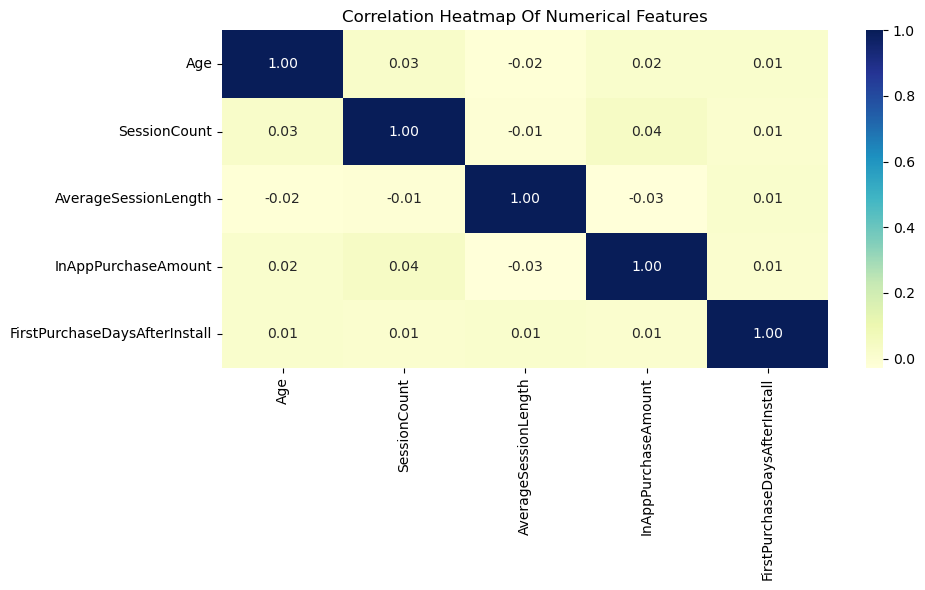

In [19]:
corr_matrix = paying_user_df[numerical_columns].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title("Correlation Heatmap Of Numerical Features")
plt.tight_layout()

### 6. Correlation Analysis: Does Engagement Drive Revenue?
A common assumption in the gaming industry is that highly engaged players—those who play longer and log in more frequently—are the ones who spend the most money. To test this hypothesis, we generated a correlation matrix. 

*Note: This analysis is performed strictly on the paying user cohort. Including Free-to-Play users (and their imputed zero or negative placeholder values) would artificially skew the mathematical relationships.*

**Key Business Insights:**
* **The Engagement Myth:** Both `SessionCount` (r ≈ 0.04) and `AverageSessionLength` (r ≈ -0.03) show virtually zero linear correlation with `InAppPurchaseAmount`. Simply keeping a player in the game longer does not automatically translate to a larger wallet size. 
* **Demographics & Timing:** User `Age` (r ≈ 0.02) and `FirstPurchaseDaysAfterInstall` (r ≈ 0.01) also show no linear relationship with purchase size. "Whales" and "Minnows" exist proportionally across all age demographics and conversion timelines.
* **Strategic Recommendation:** Since baseline playtime does not drive revenue depth, the studio should not rely purely on "time-sink" mechanics to boost Average Revenue Per User (ARPU). Instead, monetization strategies should focus on high-value event drops, gacha mechanics, and targeted cosmetic/competitive items that appeal to the Whale persona, regardless of their daily screen time.

In [20]:
df.columns

Index(['UserID', 'Age', 'Gender', 'Country', 'Device', 'GameGenre',
       'SessionCount', 'AverageSessionLength', 'SpendingSegment',
       'InAppPurchaseAmount', 'FirstPurchaseDaysAfterInstall', 'PaymentMethod',
       'LastPurchaseDate'],
      dtype='object')

In [21]:
SpendingPerSegment = paying_user_df.groupby("SpendingSegment")['InAppPurchaseAmount'].sum()

In [22]:
SpendingPerSegment

SpendingSegment
Dolphin     96288.80
Minnow      24387.37
Whale      175583.14
Name: InAppPurchaseAmount, dtype: float64

Text(0.5, 1.0, 'Purchase Amount Per User Segment')

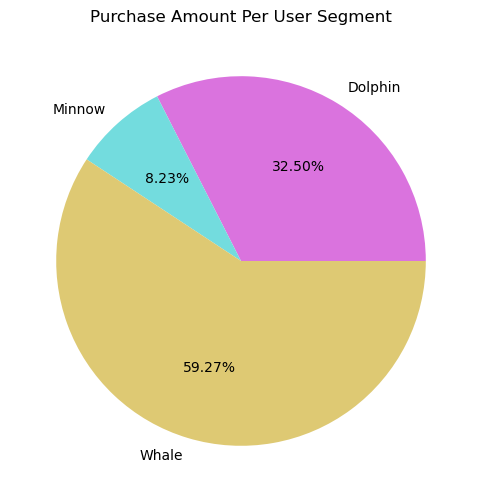

In [23]:
plt.figure(figsize=(10, 6))
plt.pie(SpendingPerSegment, labels=SpendingPerSegment.index,colors=['#DA73DE', '#73DCDE', '#DEC973'], autopct='%1.2f%%')
plt.title("Purchase Amount Per User Segment")

### 7. Revenue Distribution: The Reality of Whale Economics
In the freemium mobile gaming model—especially within titles utilizing gacha mechanics or high-value cosmetic shops—revenue is rarely distributed evenly across the player base. To understand our revenue concentration, we grouped the total in-app purchase volume by spending segment. 

**Key Business Insights:**
* **The Pareto Principle on Steroids:** A massive **~59% of all revenue** ($175k+) comes from the "Whale" segment. However, looking back at our demographic counts, Whales make up only about **2.3%** of the paying user base (68 out of 2,887 users). 
* **The Minnow Illusion:** "Minnows" account for the vast majority of the paying player volume (nearly 88% of users), yet they contribute a mere **8.2%** to the total revenue pool. 
* **Strategic Recommendation:** The studio's profitability is heavily reliant on a microscopic fraction of the player base. While keeping the F2P and Minnow populations healthy is necessary for queue times and game virality, **Customer Success and VIP retention programs** must be heavily indexed toward identifying and catering to Whale users. Losing even a small handful of these top spenders would cause a disproportionate drop in total gross revenue.

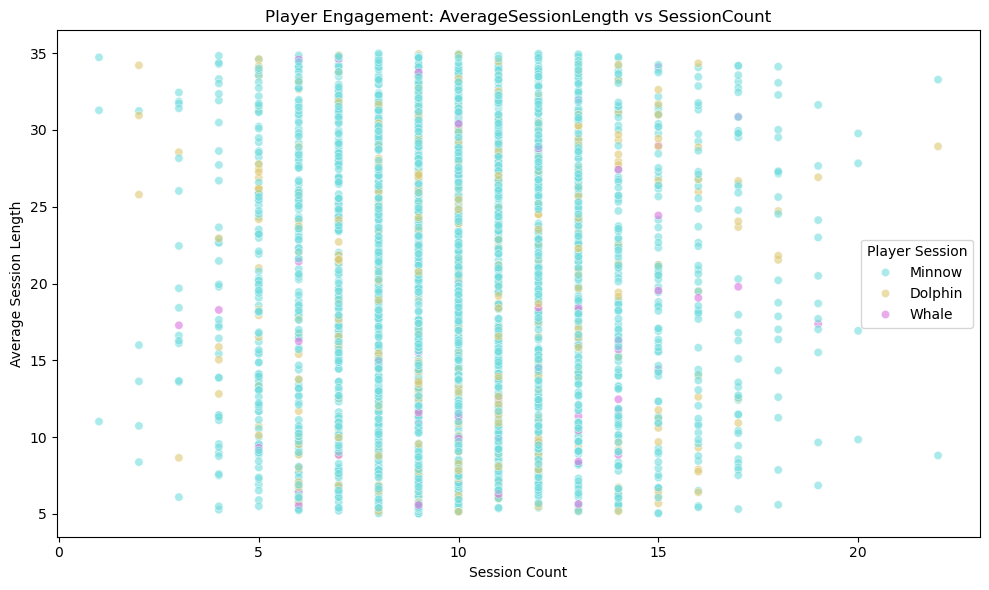

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="SessionCount", y="AverageSessionLength", hue="SpendingSegment", data=paying_user_df, alpha=0.6, palette={'Minnow': '#73DCDE', 'Dolphin': '#DEC973', 'Whale': '#DA73DE'})
plt.title("Player Engagement: AverageSessionLength vs SessionCount")
plt.ylabel("Average Session Length")
plt.xlabel("Session Count")
plt.legend(title='Player Session')
plt.tight_layout()

### 8. Player Engagement: Does Screen Time Differentiate Spenders?
To visually test the findings of our correlation matrix, we plotted player engagement (Session Count vs. Average Session Length) and color-coded the users by their `SpendingSegment`. If engagement drove spending, we would expect to see "Whales" clustered in the top-right corner (high sessions, long playtimes). 

**Key Business Insights:**
* **No Distinct "Whale" Playstyle:** The scatter plot shows that Whales (highlighted in purple) are distributed almost completely randomly across all levels of engagement. A Whale is just as likely to play a few short sessions a day as they are to play for hours.
* **Minnows Blanket the Board:** Because Minnows make up the vast majority of the paying user base, they dominate the visual space across every combination of session count and length. They are highly engaged, but at a low price point.
* **Strategic Recommendation:** Since high engagement does not naturally evolve a player from a Minnow into a Whale, the product team cannot rely on simply "increasing playtime" to boost revenue. Instead, the game requires targeted monetization triggers—such as VIP perks, limited-time exclusive cosmetics, or high-end competitive leaderboards—to convert existing playtime into higher spending.

Text(0, 0.5, 'Count of Users')

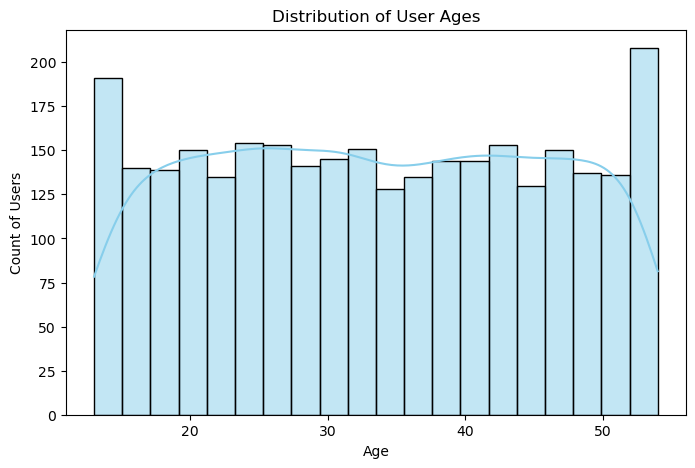

In [25]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of User Ages')
plt.xlabel('Age')
plt.ylabel('Count of Users')

### 9. Demographic Distribution: Understanding the Player Base
Before adjusting monetization and retention strategies, it is essential to understand the demographic makeup of the active user base. We generated a histogram with a Kernel Density Estimate (KDE) to visualize the spread of player ages across the application.

**Key Business Insights:**
* **Broad Audience Appeal:** The age distribution shows a wide and relatively mature spread, with the core player base falling between 23 and 44 years old (the interquartile range) and a median age of 33. 
* **The "Time-Poor, Cash-Rich" Dynamic:** A mature player base typically indicates an audience with higher disposable income but less disposable time. This demographic reality perfectly aligns with our earlier finding that session length does not dictate spending; these users are likely paying for convenience or high-value items rather than grinding for hours.
* **Strategic Recommendation:** Marketing and in-game events should be tailored to this adult demographic. Rather than purely time-intensive progression systems, offering direct-purchase conveniences, progression boosts, or premium cosmetics will likely resonate well with this specific cohort.

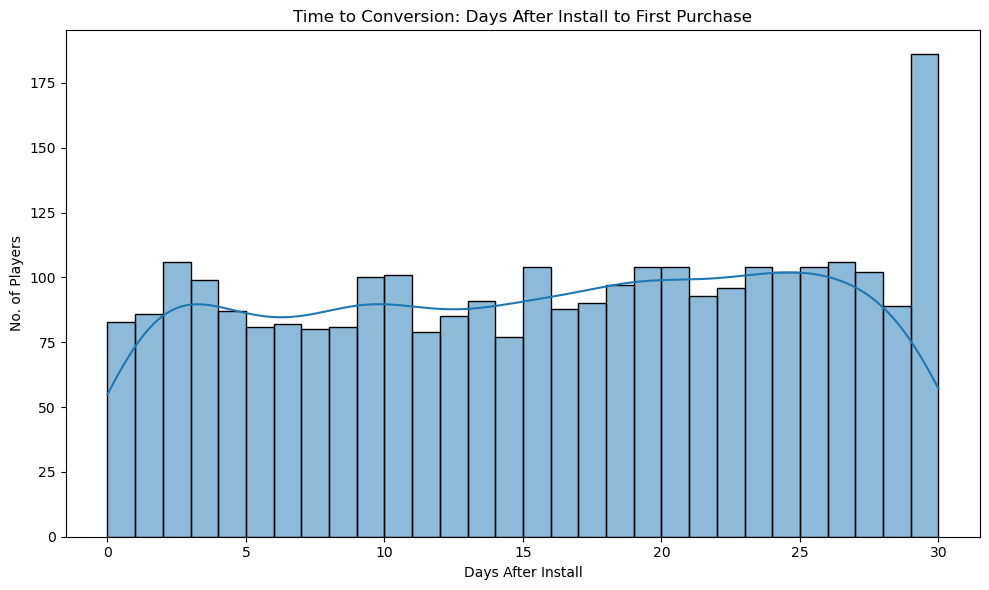

In [26]:
plt.figure(figsize=(10, 6))
conversion_df = paying_user_df[paying_user_df['FirstPurchaseDaysAfterInstall'] >= 0]
sns.histplot(conversion_df, x='FirstPurchaseDaysAfterInstall', bins=30, kde=True)
plt.title("Time to Conversion: Days After Install to First Purchase")
plt.xlabel("Days After Install")
plt.ylabel("No. of Players")
plt.tight_layout()

### 10. The Conversion Window: When Do Players Buy?
Understanding the timeline between a player installing the game and making their first purchase is critical for optimizing the First-Time User Experience (FTUE) and timing push notifications. 

**Key Business Insights:**
* **The Golden Window:** By visualizing the distribution of `FirstPurchaseDaysAfterInstall`, we can identify the peak conversion period. 
* **Strategic Recommendation:** If the majority of users convert within the first 7 days, the marketing team should front-load "Starter Pack" offers and high-value discounts early in the player's lifecycle. If the curve is flat or delayed, it suggests players need to hit a specific progression wall before feeling compelled to spend, meaning late-game retention is the most critical metric to protect.

In [27]:
average_revenue_per_country = paying_user_df.groupby('Country')['InAppPurchaseAmount'].mean().sort_values(ascending=False).reset_index(name='average_revenue')

C:\Users\akash\AppData\Local\Temp\ipykernel_20392\2162622727.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='average_revenue',y='Country', data=average_revenue_per_country, palette='viridis')


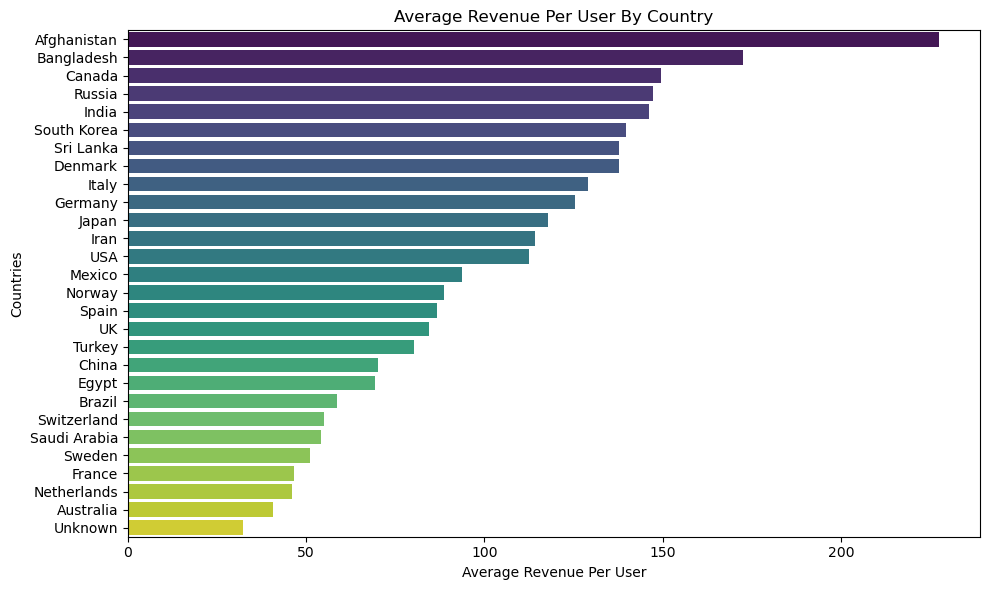

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(x='average_revenue',y='Country', data=average_revenue_per_country, palette='viridis')
plt.title("Average Revenue Per User By Country")
plt.xlabel("Average Revenue Per User")
plt.ylabel("Countries")
plt.tight_layout()

### 11. Global ARPU: Geographic Purchasing Power
Mobile games are global products, but player purchasing power and willingness to spend on digital goods varies wildly by region. To inform localized pricing and marketing strategies, we analyzed the Average Revenue Per User (ARPU) grouped by country.

**Key Business Insights:**
* **Regional Pricing Opportunities:** Identifying the countries with the highest average spend (and comparing them to the countries with the highest user volume) allows the studio to test localized pricing models. 
* **Strategic Recommendation:** If a high-volume country shows a very low ARPU, the studio might consider adjusting the cost of in-game currency or introducing lower-tier "Starter Packs" tailored to that region's purchasing parity. This can increase overall conversion rates in emerging markets while protecting the high margins seen in top-spending countries.

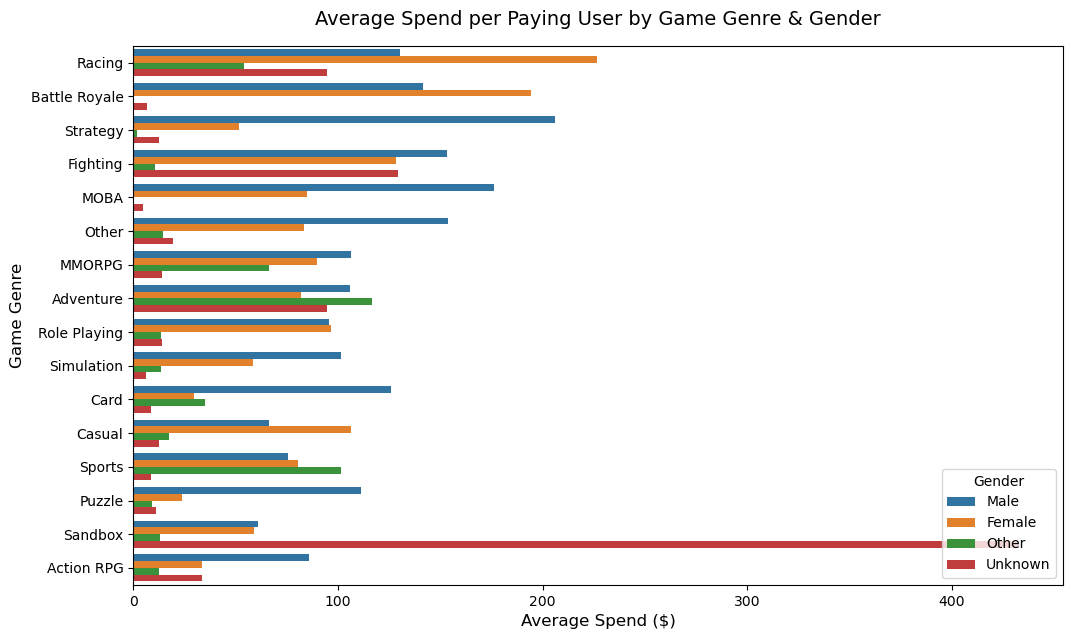

In [29]:
genre_order = paying_user_df.groupby('GameGenre')['InAppPurchaseAmount'].mean().sort_values(ascending=False).index
    
plt.figure(figsize=(12, 7))
sns.barplot(x='InAppPurchaseAmount', y='GameGenre', hue='Gender', 
                data=paying_user_df, order=genre_order, errorbar=None)
    
plt.title('Average Spend per Paying User by Game Genre & Gender', fontsize=14, pad=15)
plt.xlabel('Average Spend ($)', fontsize=12)
plt.ylabel('Game Genre', fontsize=12)
plt.legend(title='Gender', loc='lower right')

### 12. Demographic Preferences: Genre by Gender
Finally, we break down average spending by crossing two variables: `GameGenre` and `Gender`. This multi-dimensional view prevents us from making blanket assumptions about our player base.

**Key Business Insights:**
* **Targeted Ad Creative:** By understanding which demographic spends the most in specific genres (e.g., if male users spend heavily in Racing while female users dominate Casual or Puzzle spending), the studio can hyper-target its ad creatives. 
* **Strategic Recommendation:** User Acquisition (UA) teams should use these insights to tailor the artwork, copy, and platform targeting of their advertisements to the specific demographic most likely to convert in the genre they are promoting.

In [45]:
total_revenue_by_device = paying_user_df.groupby('Device')['InAppPurchaseAmount'].sum().reset_index()
avg_revenue_by_device = paying_user_df.groupby('Device')['InAppPurchaseAmount'].mean().reset_index()
summary = pd.merge(total_revenue_by_device, avg_revenue_by_device, on='Device')
summary.rename(columns={
    	'InAppPurchaseAmount_x' : 'Total_Revenue',
    	'InAppPurchaseAmount_y' : 'Average_Revenue',
}, inplace=True)
summary = summary.sort_values(by='Total_Revenue', ascending=False)

In [36]:
summary

,Device,Total_Revenue,Average_Revenue
0,Android,157721.61,94.670834
2,iOS,129487.62,111.148172
1,Other,9050.08,161.608571


C:\Users\akash\AppData\Local\Temp\ipykernel_20392\225398207.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Device', y='Total_Revenue', data=summary, palette='viridis')


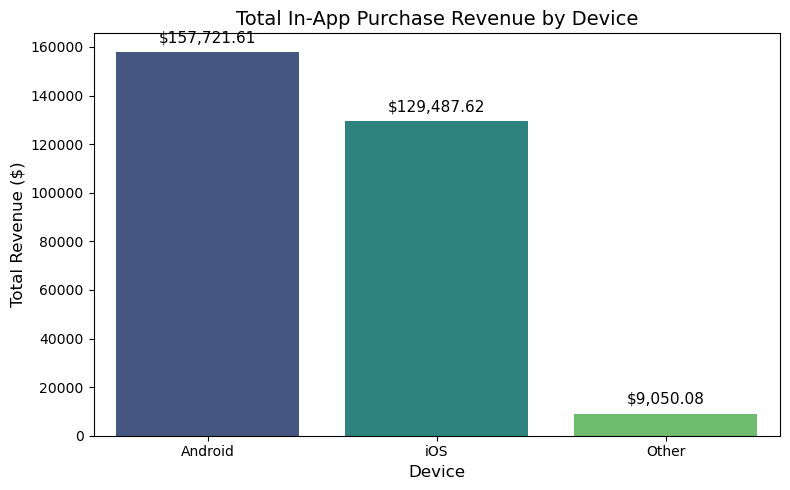

In [35]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Device', y='Total_Revenue', data=summary, palette='viridis')
plt.title('Total In-App Purchase Revenue by Device', fontsize=14)
plt.xlabel('Device', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)

ax = plt.gca()
for p in ax.patches:
    ax.annotate(f"${p.get_height():,.2f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, xytext=(0, 5), 
                textcoords='offset points')
plt.tight_layout()

### 13. Platform Economics: Volume vs. Value
To optimize our app store marketing budgets, we must understand which operating systems yield the highest financial return. We aggregated total revenue and average revenue per paying user across device types.

**Key Business Insights:**
* **Strategic Recommendation:** Evaluating total gross revenue against average user spend tells us where to aim our User Acquisition (UA) efforts. If one platform has a massive total revenue but lower average spend, it is ideal for broad volume campaigns. If the other platform has a smaller user base but a much higher average spend, it is the prime target for high-value VIP acquisition.